<a href="https://colab.research.google.com/github/mafegomez-c/Metodos-Matematicos/blob/main/Taller_CMB_Neumann.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import sph_harm_y

 A) Grafique combinaciones simples de armónicos esféricos:

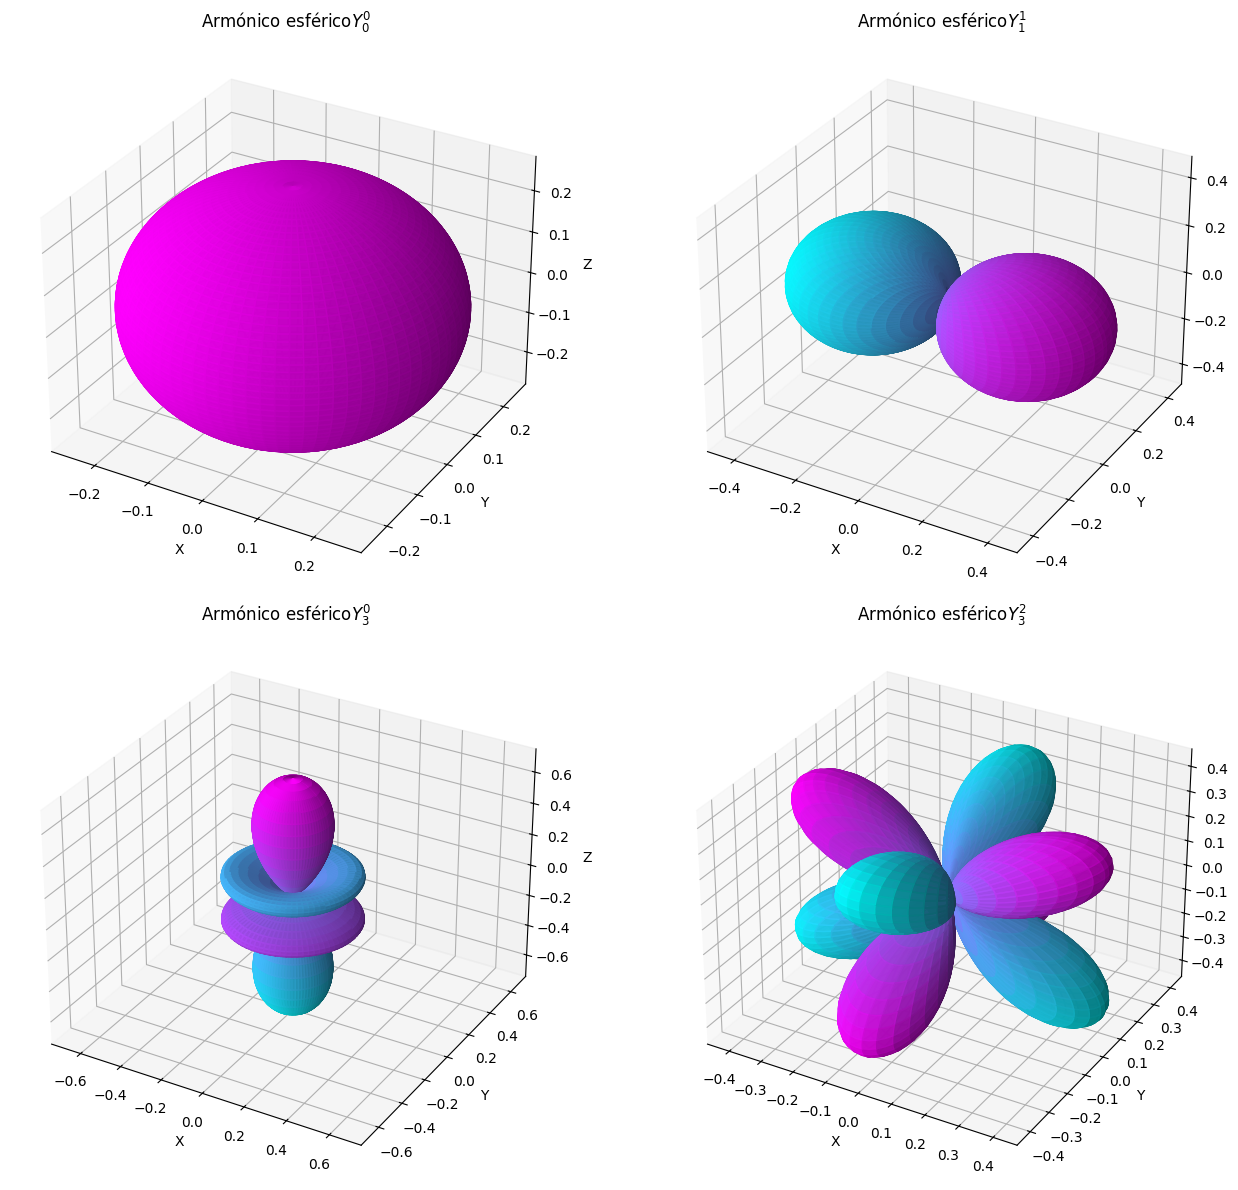

In [24]:
plt.close('all')

# Definí las coordenadas esféricas
theta = np.linspace(0, np.pi, 120)
phi = np.linspace(0, 2*np.pi, 160)
theta, phi = np.meshgrid(theta, phi)

def calcular_armonico_real(l, m, theta, phi):
    m_abs = abs(m)
    Y_pos = sph_harm_y(l, m_abs, theta, phi)
    Y_neg = sph_harm_y(l, -m_abs, theta, phi)
# ℯ^{imϕ}=cos(mϕ)+isin(mϕ)
    if m == 0:
        Y_real = sph_harm_y(l, 0, theta, phi) #Si $m=0$, el armónico esférico ya es un número puramente real
    elif m > 0:
        Y_real = (1 / np.sqrt(2)) * (Y_neg + (-1)**m * Y_pos) #Realice la suma de los armónicos esféricos para cancelar las partes imaginarias entre sí y solo sobreviven las partes reales, que dependen de coseno, para normalizar la función
    else:
        Y_real = (1j / np.sqrt(2)) * (Y_neg - (-1)**m_abs * Y_pos) #Al restar las funciones, lo que se cancela es la parte real y sobrevive la parte imaginaria que luego multiplico por i (1j) para convertirlo en un número real.

#Del plano complejo al espacio 3D (cartesianas)

    Radio = np.abs(Y_real)
    x = Radio * np.sin(theta) * np.cos(phi)
    y = Radio * np.sin(theta) * np.sin(phi)
    z = Radio * np.cos(theta)

    return x, y, z, np.real(Y_real)


def graficar_en_subeje(ax, l, m):

    x, y, z, fase = calcular_armonico_real(l, m, theta, phi)
    fase_max = np.max(np.abs(fase))
    fase_norm = (fase / fase_max + 1) / 2 if fase_max > 0 else fase
    ax.plot_surface(x, y, z, facecolors=plt.cm.cool(fase_norm),
                    rstride=2, cstride=2, antialiased=True, alpha=0.9)

    ax.set_title("Armónico esférico" f'$Y^{m}_{{{l}}}$', fontsize=12)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')

    max_val = np.max([np.max(np.abs(x)), np.max(np.abs(y)), np.max(np.abs(z))])
    if max_val < 1e-5:
        max_val = 0.1

    ax.set_xlim(-max_val, max_val)
    ax.set_ylim(-max_val, max_val)
    ax.set_zlim(-max_val, max_val)


fig = plt.figure(figsize=(14, 12))

# Gráfica 1: l=0, m=0
ax1 = fig.add_subplot(2, 2, 1, projection='3d')
graficar_en_subeje(ax1, l=0, m=0)

# Gráfica 2:l=1, m=1
ax2 = fig.add_subplot(2, 2, 2, projection='3d')
graficar_en_subeje(ax2, l=1, m=1)

# Gráfica 3: l=3, m=0
ax3 = fig.add_subplot(2, 2, 3, projection='3d')
graficar_en_subeje(ax3, l=3, m=0)

# Gráfica 4: l=3, m=2
ax4 = fig.add_subplot(2, 2, 4, projection='3d')
graficar_en_subeje(ax4, l=3, m=2)

plt.tight_layout()
plt.show()